# Avila landslide-line inventory — slope & aspect

Slope/aspect for the 640 landslide **lines** in the Avila draft inventory
(`VenLS_AvilaDRAFT_15July2026`, 2026-07-15), from the 30 m Copernicus DEM.

Lines have no interior to run zonal stats on, so slope and aspect were sampled
at points densified every ~15 m along each line, then aggregated per line:

- `slope_mean/max` — slope the line traverses (degrees)
- `aspect_deg` — **circular** mean of DEM aspect along the line (downslope azimuth)
- `aspect_R` — aspect consistency, 0 (varies) → 1 (single direction)
- `length_m` — line length in meters (UTM 19N)

The rose comes in two weightings: **count** (each line = 1) and **length**
(each line contributes its mapped length), so long runout tracks count more in
the length version.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

SRC = "../data/usgs_avila/venls_avila_inventory_line_20260715.geojson"
gdf = gpd.read_file(SRC)
ls = gdf[gdf.aspect_deg.notna() & gdf.slope_max.notna() & (gdf.aspect_dir != "flat")].copy()
print(f"{len(gdf)} lines ({len(ls)} with a defined aspect) | total length {gdf.length_m.sum()/1000:.1f} km")
ls[["slope_mean", "slope_max", "aspect_deg", "length_m"]].describe().round(1)

640 lines (616 with a defined aspect) | total length 52.4 km


,slope_mean,slope_max,aspect_deg,length_m
count,616.0,616.0,616.0,616.0
mean,36.5,40.8,130.7,83.0
std,8.2,8.4,117.6,94.3
min,4.9,4.9,1.0,6.8
25%,31.9,36.4,42.0,33.9
50%,37.1,41.4,77.5,57.2
75%,41.9,46.0,251.5,100.9
max,60.6,87.8,360.0,1124.6


## Rose setup (shared)

In [2]:
N = 16
SLOPE_BINS = [0, 20, 30, 40, 50, 90]
SLOPE_LABELS = ["<20°", "20–30°", "30–40°", "40–50°", "≥50°"]
SLOPE_COLORS = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]
ls["sbin"] = np.digitize(ls["slope_max"], SLOPE_BINS[1:-1])
ls["sector"] = np.floor(((ls["aspect_deg"] + 360 / N / 2) % 360) / (360 / N)).astype(int)
theta = np.deg2rad(np.arange(N) * (360 / N))
petal_w = (2 * np.pi / N) * 0.9


def stacked_rose(weight_col, title, unit, savename):
    stack = np.zeros((N, len(SLOPE_LABELS)))
    for sec, sb, w in zip(ls["sector"], ls["sbin"], ls[weight_col]):
        stack[int(sec), int(sb)] += w
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    bottom = np.zeros(N)
    for b in range(len(SLOPE_LABELS)):
        ax.bar(theta, stack[:, b], width=petal_w, bottom=bottom,
               color=SLOPE_COLORS[b], edgecolor="white", linewidth=0.5,
               label=SLOPE_LABELS[b])
        bottom += stack[:, b]
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_title(f"{title}\n(n={len(ls)} lines; petal = {unit})", pad=20)
    ax.legend(title="max slope", loc="upper left",
              bbox_to_anchor=(1.05, 1.05), frameon=False)
    plt.tight_layout()
    plt.savefig(savename, dpi=150, bbox_inches="tight")
    plt.show()
    return stack

## Rose 1 — by COUNT
Petal length = number of landslide lines facing that way; color = max slope.

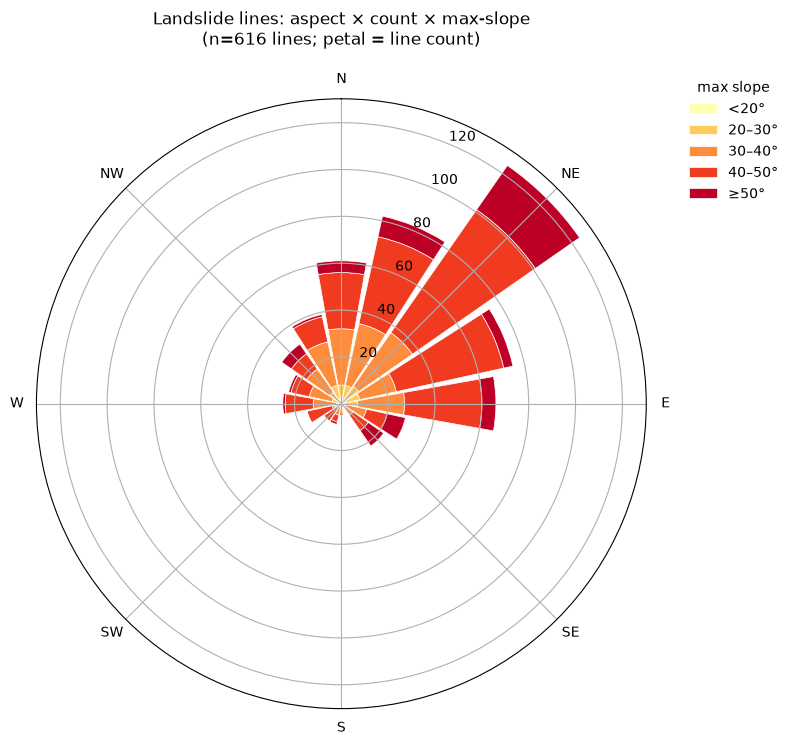

In [3]:
ls["one"] = 1
_ = stacked_rose("one", "Landslide lines: aspect × count × max-slope",
                 "line count", "avila_rose_count.png")

## Rose 2 — by LENGTH
Petal length = **total mapped line length (m)** facing that way; color = max
slope. Long runout tracks weigh more than short ones, so this can point
differently than the count rose.

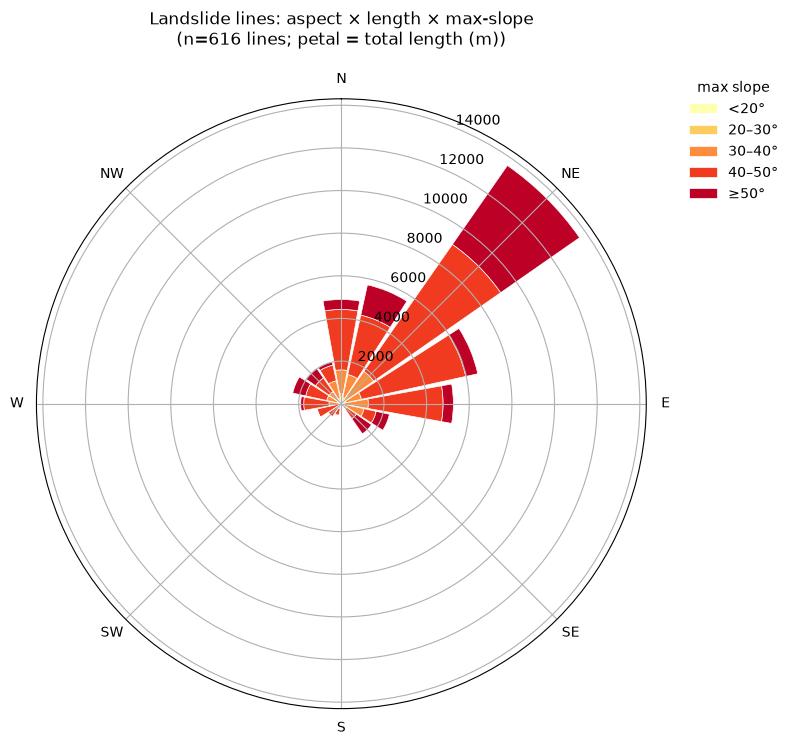

In [4]:
_ = stacked_rose("length_m", "Landslide lines: aspect × length × max-slope",
                 "total length (m)", "avila_rose_length.png")

## Count vs length by direction

In [5]:
ls["dir8"] = np.floor(((ls.aspect_deg + 22.5) % 360) / 45).astype(int)
by = ls.groupby("dir8").agg(count=("length_m", "size"), length_m=("length_m", "sum"))
by = by.reindex(range(8)).fillna(0)
by.index = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
by["count_pct"] = (100 * by["count"] / by["count"].sum()).round(1)
by["length_pct"] = (100 * by.length_m / by.length_m.sum()).round(1)
print(by[["count", "count_pct", "length_m", "length_pct"]].round(0))

    count  count_pct  length_m  length_pct
N     120       20.0    8812.0        17.0
NE    218       35.0   20898.0        41.0
E     109       18.0    9144.0        18.0
SE     36        6.0    2720.0         5.0
S      11        2.0     646.0         1.0
SW     21        3.0    1717.0         3.0
W      41        7.0    3630.0         7.0
NW     60       10.0    3548.0         7.0


## Slope magnitude along lines

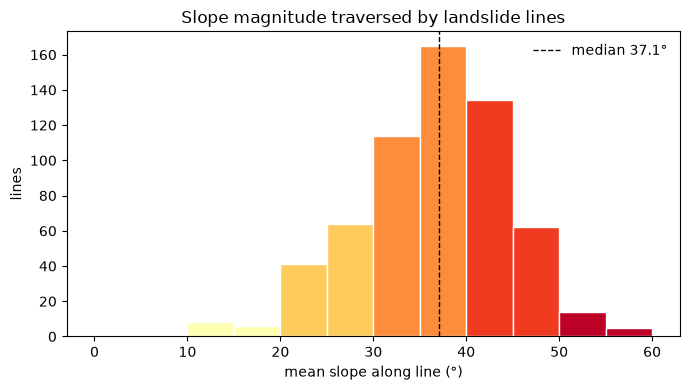

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
n, bins_, patches = ax.hist(ls["slope_mean"], bins=np.arange(0, 65, 5), edgecolor="white")
for patch, left in zip(patches, bins_[:-1]):
    b = np.digitize(left + 2.5, SLOPE_BINS[1:-1])
    patch.set_facecolor(SLOPE_COLORS[min(b, len(SLOPE_COLORS) - 1)])
ax.axvline(ls["slope_mean"].median(), color="k", ls="--", lw=1,
           label=f"median {ls['slope_mean'].median():.1f}°")
ax.set_xlabel("mean slope along line (°)"); ax.set_ylabel("lines")
ax.set_title("Slope magnitude traversed by landslide lines")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Landslide size distribution

Mapped **line length** per landslide line (UTM 19N), across all 640 lines.
Length is a proxy for runout/scar extent for these line features. The
distribution is strongly right-skewed — most lines are short, with a long tail
of large runout tracks — so it's shown on a log length axis.

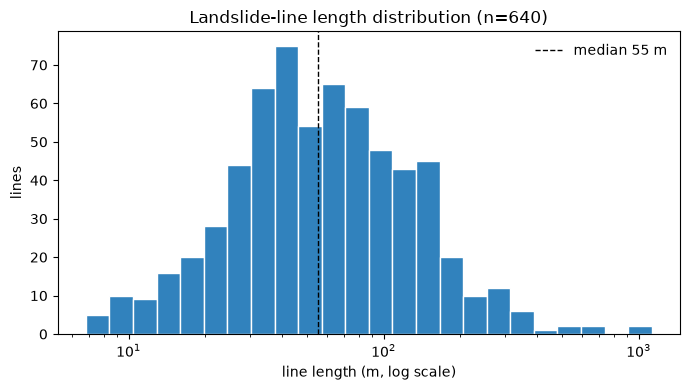

count     640.0
mean       81.9
std        92.9
min         6.8
25%        33.8
50%        55.0
75%       100.2
max      1124.6
Name: length_m, dtype: float64


In [7]:
length_m = gdf["length_m"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(np.log10(length_m.min()), np.log10(length_m.max()), 25)
ax.hist(length_m, bins=bins, color="#3182bd", edgecolor="white")
ax.set_xscale("log")
ax.axvline(length_m.median(), color="k", ls="--", lw=1,
           label=f"median {length_m.median():.0f} m")
ax.set_xlabel("line length (m, log scale)"); ax.set_ylabel("lines")
ax.set_title(f"Landslide-line length distribution (n={len(length_m)})")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("avila_length_hist.png", dpi=150, bbox_inches="tight")
plt.show()

print(length_m.describe().round(1))